# Split Comparison: privateboost vs Optimal

This notebook compares the splits found by privateboost (using secret-shared gradient histograms) against optimal splits computed directly on raw data.

We explore four visualization approaches:
1. **Split threshold comparison** - Where each method places the split on a feature axis
2. **Information gain comparison** - Bar chart of gains achieved
3. **Decision boundary overlay** - Both boundaries on a 2D scatter plot
4. **Histogram fidelity** - Reconstructed vs true gradient histogram

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from privateboost import Client, ShareHolder, Aggregator

np.random.seed(42)

## Load Data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv(url, names=columns, na_values="?")
df = df.dropna()
df["target"] = (df["target"] > 0).astype(int)

FEATURES = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

# Use all data for this analysis
print(f"Samples: {len(df)}, Features: {len(FEATURES)}")

Samples: 297, Features: 13


## Setup privateboost

In [3]:
N_SHAREHOLDERS = 3
N_BINS = 10
LAMBDA_REG = 1.0

aggregator = Aggregator(n_bins=N_BINS)
shareholders = [ShareHolder(i, aggregator) for i in range(N_SHAREHOLDERS)]

clients = [
    Client(
        client_id=f"patient_{idx}",
        features=[float(row[name]) for name in FEATURES],
        target=float(row["target"]),
        shareholders=shareholders,
    )
    for idx, row in df.iterrows()
]

# Compute bins
for client in clients:
    client.submit_feature_shares_for_stats()
for sh in shareholders:
    sh.submit_stats()
bins = aggregator.define_bins()

# Initialize predictions to mean
initial_pred = float(aggregator.means[-1])
for client in clients:
    client.prediction = initial_pred

print(f"Initial prediction: {initial_pred:.4f}")

Initial prediction: 0.4613


## Get First Split from privateboost

In [4]:
# Submit gradients for root node
for client in clients:
    client.submit_gradients(bins, active_nodes=[0], loss="squared")
for sh in shareholders:
    sh.submit_gradients()

# Find best split
pb_splits = aggregator.find_best_splits(lambda_reg=LAMBDA_REG)
pb_split = pb_splits[0]

print(f"privateboost split:")
print(f"  Feature: {FEATURES[pb_split.feature_idx]} (idx={pb_split.feature_idx})")
print(f"  Threshold: {pb_split.threshold:.4f}")
print(f"  Gain: {pb_split.gain:.4f}")

privateboost split:
  Feature: thal (idx=12)
  Threshold: 5.8919
  Gain: 20.2012


## Compute Optimal Split (on raw data)

In [5]:
def compute_optimal_split(X, y, predictions, lambda_reg=1.0):
    """Find optimal split by exhaustive search on raw data."""
    n_samples, n_features = X.shape
    
    # Compute gradients (squared loss)
    gradients = predictions - y
    hessians = np.ones_like(gradients)
    
    total_g = gradients.sum()
    total_h = hessians.sum()
    base_score = (total_g ** 2) / (total_h + lambda_reg)
    
    best_gain = 0
    best_feature = None
    best_threshold = None
    
    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        sorted_indices = np.argsort(feature_values)
        sorted_values = feature_values[sorted_indices]
        sorted_g = gradients[sorted_indices]
        sorted_h = hessians[sorted_indices]
        
        g_left = 0
        h_left = 0
        
        for i in range(n_samples - 1):
            g_left += sorted_g[i]
            h_left += sorted_h[i]
            g_right = total_g - g_left
            h_right = total_h - h_left
            
            # Skip if same value as next
            if sorted_values[i] == sorted_values[i + 1]:
                continue
            
            if h_left < 0.1 or h_right < 0.1:
                continue
            
            left_score = (g_left ** 2) / (h_left + lambda_reg)
            right_score = (g_right ** 2) / (h_right + lambda_reg)
            gain = left_score + right_score - base_score
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = (sorted_values[i] + sorted_values[i + 1]) / 2
    
    return best_feature, best_threshold, best_gain

X = df[FEATURES].values.astype(float)
y = df["target"].values.astype(float)
predictions = np.full(len(y), initial_pred)

opt_feature, opt_threshold, opt_gain = compute_optimal_split(X, y, predictions, LAMBDA_REG)

print(f"Optimal split:")
print(f"  Feature: {FEATURES[opt_feature]} (idx={opt_feature})")
print(f"  Threshold: {opt_threshold:.4f}")
print(f"  Gain: {opt_gain:.4f}")

Optimal split:
  Feature: thal (idx=12)
  Threshold: 4.5000
  Gain: 20.2012


## Visualization A: Split Threshold Comparison

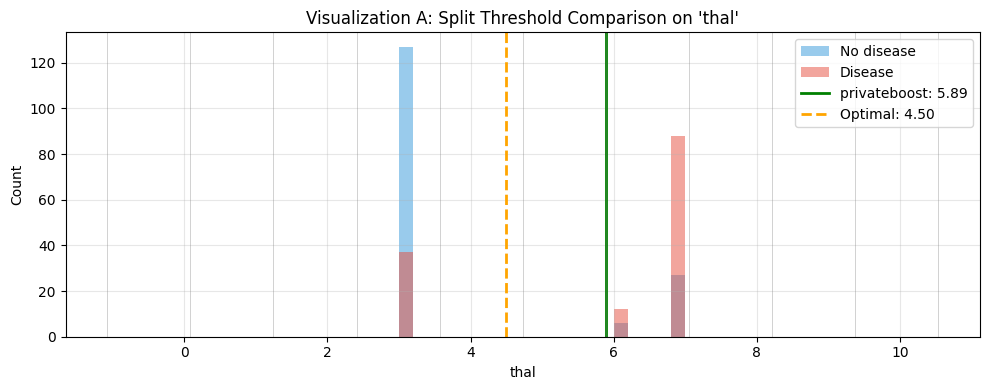

In [6]:
# Compare on the feature that privateboost chose
feature_idx = pb_split.feature_idx
feature_name = FEATURES[feature_idx]
feature_values = X[:, feature_idx]

fig, ax = plt.subplots(figsize=(10, 4))

# Histogram of feature values
ax.hist(feature_values[y == 0], bins=20, alpha=0.5, label="No disease", color="#3498db")
ax.hist(feature_values[y == 1], bins=20, alpha=0.5, label="Disease", color="#e74c3c")

# privateboost split
ax.axvline(pb_split.threshold, color="green", linewidth=2, linestyle="-", label=f"privateboost: {pb_split.threshold:.2f}")

# Optimal split (if same feature)
if opt_feature == feature_idx:
    ax.axvline(opt_threshold, color="orange", linewidth=2, linestyle="--", label=f"Optimal: {opt_threshold:.2f}")

# Bin edges
bin_config = bins[feature_idx]
for edge in bin_config.inner_edges:
    ax.axvline(edge, color="gray", linewidth=0.5, alpha=0.5)

ax.set_xlabel(feature_name)
ax.set_ylabel("Count")
ax.set_title(f"Visualization A: Split Threshold Comparison on '{feature_name}'")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization B: Information Gain Comparison

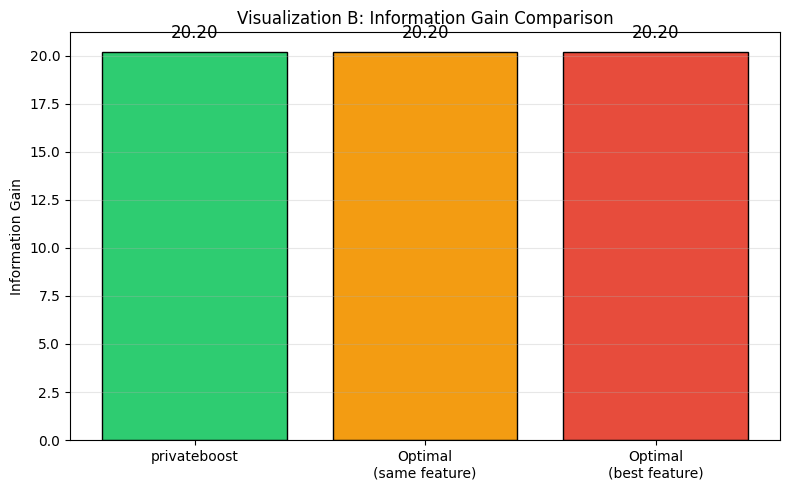


Gain retention: 100.0% of optimal


In [7]:
# Compute optimal gain for the same feature privateboost chose
def compute_optimal_split_for_feature(X, y, predictions, feature_idx, lambda_reg=1.0):
    """Find optimal split for a specific feature."""
    gradients = predictions - y
    hessians = np.ones_like(gradients)
    
    total_g = gradients.sum()
    total_h = hessians.sum()
    base_score = (total_g ** 2) / (total_h + lambda_reg)
    
    feature_values = X[:, feature_idx]
    sorted_indices = np.argsort(feature_values)
    sorted_values = feature_values[sorted_indices]
    sorted_g = gradients[sorted_indices]
    sorted_h = hessians[sorted_indices]
    
    best_gain = 0
    best_threshold = None
    
    g_left = 0
    h_left = 0
    
    for i in range(len(sorted_values) - 1):
        g_left += sorted_g[i]
        h_left += sorted_h[i]
        g_right = total_g - g_left
        h_right = total_h - h_left
        
        if sorted_values[i] == sorted_values[i + 1]:
            continue
        
        if h_left < 0.1 or h_right < 0.1:
            continue
        
        left_score = (g_left ** 2) / (h_left + lambda_reg)
        right_score = (g_right ** 2) / (h_right + lambda_reg)
        gain = left_score + right_score - base_score
        
        if gain > best_gain:
            best_gain = gain
            best_threshold = (sorted_values[i] + sorted_values[i + 1]) / 2
    
    return best_threshold, best_gain

opt_thresh_same_feat, opt_gain_same_feat = compute_optimal_split_for_feature(
    X, y, predictions, pb_split.feature_idx, LAMBDA_REG
)

fig, ax = plt.subplots(figsize=(8, 5))

methods = ["privateboost", "Optimal\n(same feature)", "Optimal\n(best feature)"]
gains = [pb_split.gain, opt_gain_same_feat, opt_gain]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

bars = ax.bar(methods, gains, color=colors, edgecolor="black")

for bar, gain in zip(bars, gains):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f"{gain:.2f}", ha="center", va="bottom", fontsize=12)

ax.set_ylabel("Information Gain")
ax.set_title("Visualization B: Information Gain Comparison")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"\nGain retention: {pb_split.gain / opt_gain * 100:.1f}% of optimal")

## Visualization C: Decision Boundary Overlay (2D)

/tmp/ipykernel_387349/1635643824.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


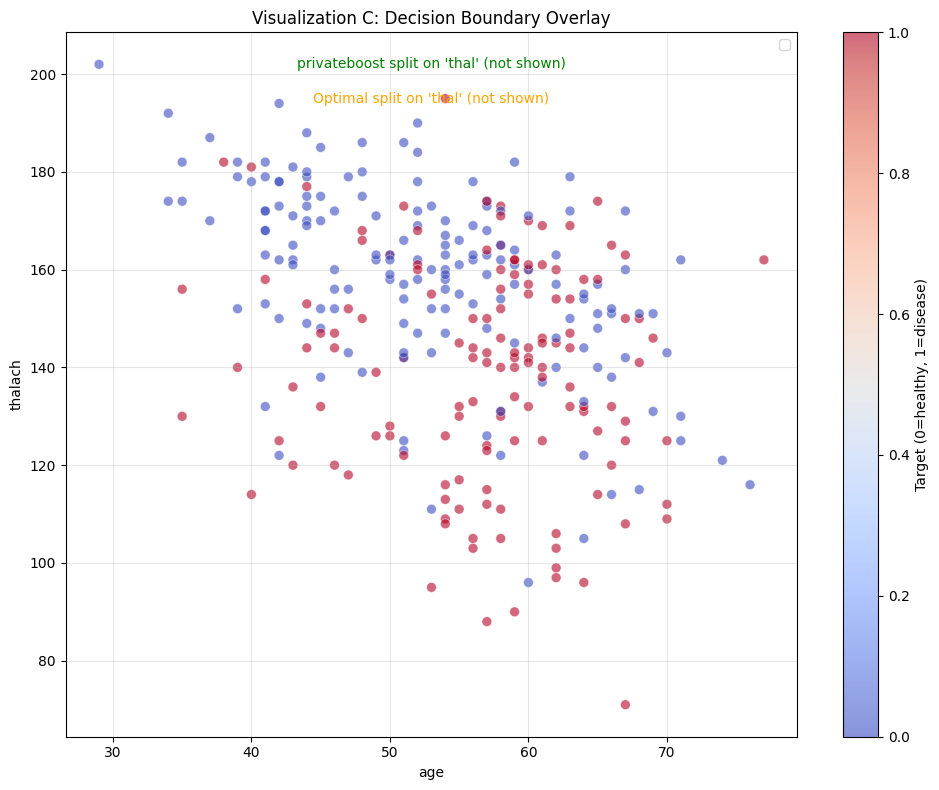

In [8]:
# Pick two informative features for 2D visualization
feat1_name, feat2_name = "age", "thalach"  # age and max heart rate
feat1_idx = FEATURES.index(feat1_name)
feat2_idx = FEATURES.index(feat2_name)

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
scatter = ax.scatter(X[:, feat1_idx], X[:, feat2_idx], c=y, cmap="coolwarm", 
                     alpha=0.6, s=50, edgecolor="white", linewidth=0.5)

# privateboost split
if pb_split.feature_idx == feat1_idx:
    ax.axvline(pb_split.threshold, color="green", linewidth=2, label=f"privateboost: {feat1_name}={pb_split.threshold:.1f}")
elif pb_split.feature_idx == feat2_idx:
    ax.axhline(pb_split.threshold, color="green", linewidth=2, label=f"privateboost: {feat2_name}={pb_split.threshold:.1f}")
else:
    ax.text(0.5, 0.95, f"privateboost split on '{FEATURES[pb_split.feature_idx]}' (not shown)", 
            transform=ax.transAxes, ha="center", fontsize=10, color="green")

# Optimal split
if opt_feature == feat1_idx:
    ax.axvline(opt_threshold, color="orange", linewidth=2, linestyle="--", label=f"Optimal: {feat1_name}={opt_threshold:.1f}")
elif opt_feature == feat2_idx:
    ax.axhline(opt_threshold, color="orange", linewidth=2, linestyle="--", label=f"Optimal: {feat2_name}={opt_threshold:.1f}")
else:
    ax.text(0.5, 0.90, f"Optimal split on '{FEATURES[opt_feature]}' (not shown)", 
            transform=ax.transAxes, ha="center", fontsize=10, color="orange")

ax.set_xlabel(feat1_name)
ax.set_ylabel(feat2_name)
ax.set_title("Visualization C: Decision Boundary Overlay")
ax.legend(loc="upper right")
plt.colorbar(scatter, label="Target (0=healthy, 1=disease)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization D: Histogram Fidelity

In [9]:
# Rerun to capture gradient histograms
aggregator2 = Aggregator(n_bins=N_BINS)
shareholders2 = [ShareHolder(i, aggregator2) for i in range(N_SHAREHOLDERS)]

clients2 = [
    Client(
        client_id=f"patient_{idx}",
        features=[float(row[name]) for name in FEATURES],
        target=float(row["target"]),
        shareholders=shareholders2,
    )
    for idx, row in df.iterrows()
]

for client in clients2:
    client.submit_feature_shares_for_stats()
for sh in shareholders2:
    sh.submit_stats()
bins2 = aggregator2.define_bins()

for client in clients2:
    client.prediction = initial_pred

for client in clients2:
    client.submit_gradients(bins2, active_nodes=[0], loss="squared")
for sh in shareholders2:
    sh.submit_gradients()

# Access reconstructed histograms (we need to peek inside)
reconstructed = aggregator2._reconstruct_histograms()
pb_grad_hist = reconstructed[0][pb_split.feature_idx].gradient
pb_hess_hist = reconstructed[0][pb_split.feature_idx].hessian

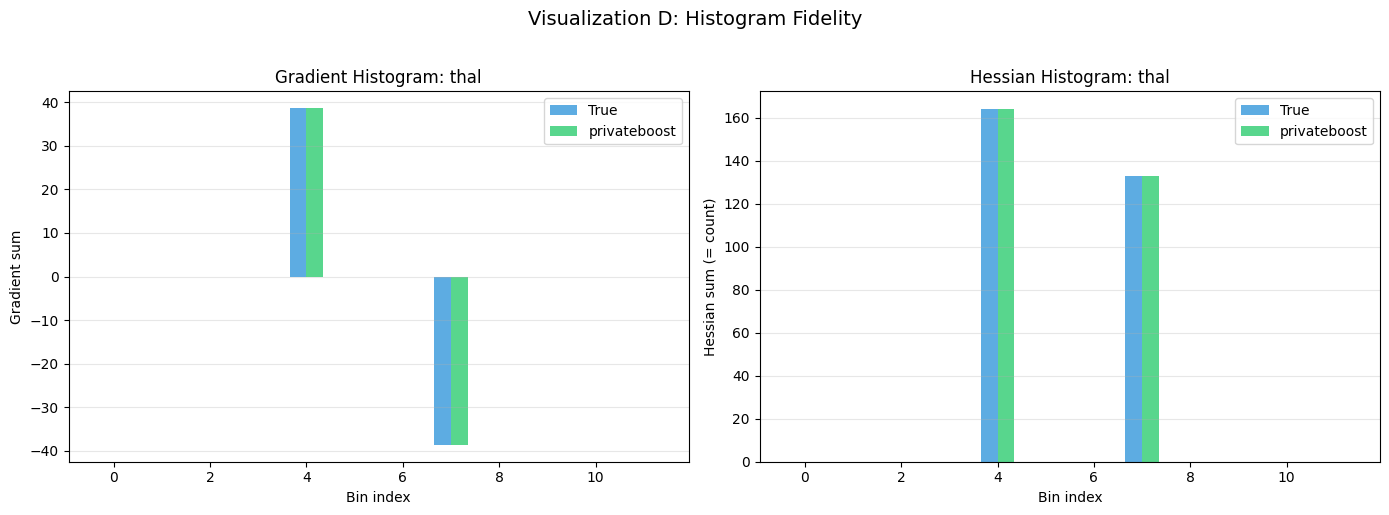


Total absolute error:
  Gradient histogram: 0.000000
  Hessian histogram: 0.000000


In [10]:
# Compute true histogram from raw data
feature_idx = pb_split.feature_idx
bin_config = bins[feature_idx]
n_total_bins = bin_config.n_bins + 2

gradients = predictions - y
hessians = np.ones_like(gradients)

true_grad_hist = np.zeros(n_total_bins)
true_hess_hist = np.zeros(n_total_bins)

for i in range(len(X)):
    value = X[i, feature_idx]
    bin_idx = int(np.searchsorted(bin_config.edges, value, side="right")) - 1
    bin_idx = max(0, min(bin_idx, n_total_bins - 1))
    true_grad_hist[bin_idx] += gradients[i]
    true_hess_hist[bin_idx] += hessians[i]

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(n_total_bins)
width = 0.35

# Gradient histogram
ax1 = axes[0]
ax1.bar(x - width/2, true_grad_hist, width, label="True", color="#3498db", alpha=0.8)
ax1.bar(x + width/2, pb_grad_hist, width, label="privateboost", color="#2ecc71", alpha=0.8)
ax1.set_xlabel("Bin index")
ax1.set_ylabel("Gradient sum")
ax1.set_title(f"Gradient Histogram: {FEATURES[feature_idx]}")
ax1.legend()
ax1.grid(alpha=0.3, axis="y")

# Hessian histogram
ax2 = axes[1]
ax2.bar(x - width/2, true_hess_hist, width, label="True", color="#3498db", alpha=0.8)
ax2.bar(x + width/2, pb_hess_hist, width, label="privateboost", color="#2ecc71", alpha=0.8)
ax2.set_xlabel("Bin index")
ax2.set_ylabel("Hessian sum (= count)")
ax2.set_title(f"Hessian Histogram: {FEATURES[feature_idx]}")
ax2.legend()
ax2.grid(alpha=0.3, axis="y")

plt.suptitle("Visualization D: Histogram Fidelity", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Compute error metrics
grad_error = np.abs(pb_grad_hist - true_grad_hist).sum()
hess_error = np.abs(pb_hess_hist - true_hess_hist).sum()
print(f"\nTotal absolute error:")
print(f"  Gradient histogram: {grad_error:.6f}")
print(f"  Hessian histogram: {hess_error:.6f}")

## Summary

In [11]:
print("=" * 60)
print("SPLIT COMPARISON SUMMARY")
print("=" * 60)
print(f"\nprivateboost split:")
print(f"  Feature: {FEATURES[pb_split.feature_idx]}")
print(f"  Threshold: {pb_split.threshold:.4f}")
print(f"  Gain: {pb_split.gain:.4f}")
print(f"\nOptimal split:")
print(f"  Feature: {FEATURES[opt_feature]}")
print(f"  Threshold: {opt_threshold:.4f}")
print(f"  Gain: {opt_gain:.4f}")
print(f"\nComparison:")
print(f"  Same feature chosen: {pb_split.feature_idx == opt_feature}")
if pb_split.feature_idx == opt_feature:
    threshold_diff = abs(pb_split.threshold - opt_threshold)
    print(f"  Threshold difference: {threshold_diff:.4f}")
print(f"  Gain retention: {pb_split.gain / opt_gain * 100:.1f}%")

SPLIT COMPARISON SUMMARY

privateboost split:
  Feature: thal
  Threshold: 5.8919
  Gain: 20.2012

Optimal split:
  Feature: thal
  Threshold: 4.5000
  Gain: 20.2012

Comparison:
  Same feature chosen: True
  Threshold difference: 1.3919
  Gain retention: 100.0%


## All-Features Comparison

Now let's compare privateboost vs optimal splits across ALL features.

In [12]:
# Compute optimal and privateboost splits for ALL features
def compute_pb_split_for_feature(X, y, predictions, feature_idx, bins, lambda_reg=1.0):
    """Simulate privateboost split for a specific feature using histogram binning."""
    gradients = predictions - y
    hessians = np.ones_like(gradients)
    
    total_g = gradients.sum()
    total_h = hessians.sum()
    base_score = (total_g ** 2) / (total_h + lambda_reg)
    
    bin_config = bins[feature_idx]
    n_total_bins = bin_config.n_bins + 2
    
    # Build histogram
    grad_hist = np.zeros(n_total_bins)
    hess_hist = np.zeros(n_total_bins)
    
    for i in range(len(X)):
        value = X[i, feature_idx]
        bin_idx = int(np.searchsorted(bin_config.edges, value, side="right")) - 1
        bin_idx = max(0, min(bin_idx, n_total_bins - 1))
        grad_hist[bin_idx] += gradients[i]
        hess_hist[bin_idx] += hessians[i]
    
    # Find best split from histogram
    g_cumsum = np.cumsum(grad_hist)
    h_cumsum = np.cumsum(hess_hist)
    
    best_gain = 0
    best_threshold = None
    
    for i in range(len(grad_hist) - 1):
        g_left = g_cumsum[i]
        h_left = h_cumsum[i]
        g_right = total_g - g_left
        h_right = total_h - h_left
        
        if h_left < 0.1 or h_right < 0.1:
            continue
        
        left_score = (g_left ** 2) / (h_left + lambda_reg)
        right_score = (g_right ** 2) / (h_right + lambda_reg)
        gain = left_score + right_score - base_score
        
        if gain > best_gain:
            best_gain = gain
            best_threshold = bin_config.edges[i + 1]
    
    return best_threshold, best_gain

# Compute for all features
all_features_data = []

for feat_idx, feat_name in enumerate(FEATURES):
    opt_thresh, opt_g = compute_optimal_split_for_feature(X, y, predictions, feat_idx, LAMBDA_REG)
    pb_thresh, pb_g = compute_pb_split_for_feature(X, y, predictions, feat_idx, bins, LAMBDA_REG)
    
    feat_min = X[:, feat_idx].min()
    feat_max = X[:, feat_idx].max()
    feat_range = feat_max - feat_min
    
    all_features_data.append({
        'feature': feat_name,
        'feature_idx': feat_idx,
        'opt_threshold': opt_thresh,
        'opt_gain': opt_g,
        'pb_threshold': pb_thresh,
        'pb_gain': pb_g,
        'feat_min': feat_min,
        'feat_max': feat_max,
        'feat_range': feat_range,
        'threshold_diff': abs(pb_thresh - opt_thresh) if (pb_thresh and opt_thresh) else None,
        'gain_retention': (pb_g / opt_g * 100) if opt_g > 0 else 100,
    })

results_df = pd.DataFrame(all_features_data)
print(results_df[['feature', 'opt_threshold', 'pb_threshold', 'threshold_diff', 'opt_gain', 'pb_gain', 'gain_retention']].to_string(index=False))

 feature  opt_threshold  pb_threshold  threshold_diff  opt_gain   pb_gain  gain_retention
     age           54.5     54.542088        0.042088  6.305443  6.305443      100.000000
     sex            0.5      0.115514        0.384486  5.674003  5.674003      100.000000
      cp            3.5      3.158249        0.341751 18.846647 18.846647      100.000000
trestbps          143.0    142.333330        0.666670  1.588691  1.588691      100.000000
    chol          272.0    278.496151        6.496151  1.726694  1.565010       90.636242
     fbs            0.5      0.144781        0.355219  0.000725  0.000725      100.000000
 restecg            0.5      0.400690        0.099310  2.194829  2.194829      100.000000
 thalach          147.5    149.599327        2.099327 13.042215 11.050372       84.727731
   exang            0.5      0.045217        0.454783 12.991992 12.991992      100.000000
 oldpeak            1.7      1.754050        0.054050 11.906870 11.906870      100.000000
   slope  

### Option A: Threshold Comparison Scatter

X = optimal threshold (normalized), Y = privateboost threshold (normalized). Points on diagonal = perfect match.

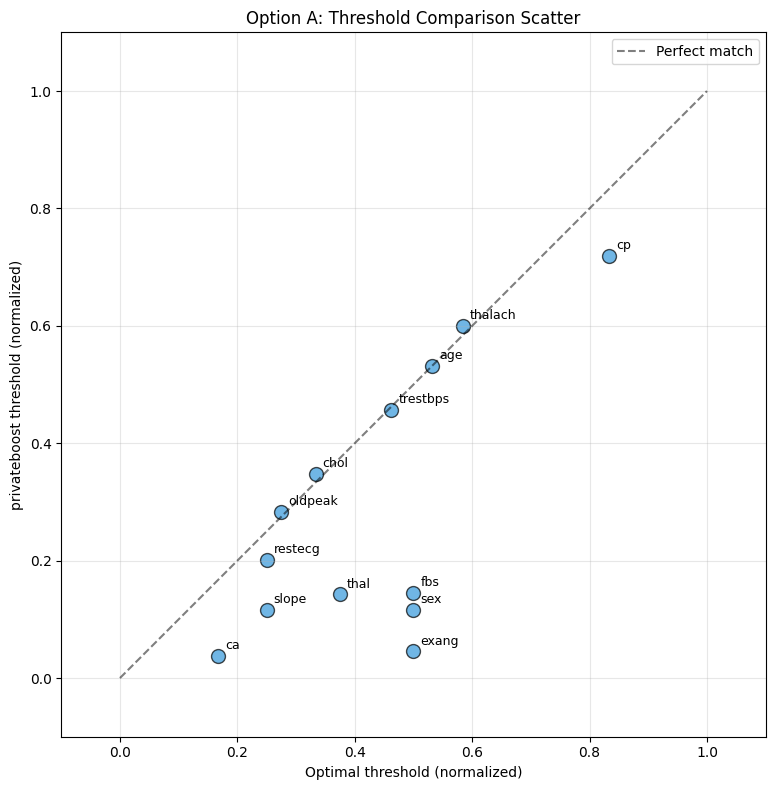

In [13]:
# Normalize thresholds to [0, 1] range for each feature
fig, ax = plt.subplots(figsize=(8, 8))

opt_norm = []
pb_norm = []
labels = []

for row in all_features_data:
    if row['opt_threshold'] is not None and row['pb_threshold'] is not None and row['feat_range'] > 0:
        opt_n = (row['opt_threshold'] - row['feat_min']) / row['feat_range']
        pb_n = (row['pb_threshold'] - row['feat_min']) / row['feat_range']
        opt_norm.append(opt_n)
        pb_norm.append(pb_n)
        labels.append(row['feature'])

ax.scatter(opt_norm, pb_norm, s=100, c='#3498db', edgecolor='black', alpha=0.7)

# Add feature labels
for i, label in enumerate(labels):
    ax.annotate(label, (opt_norm[i], pb_norm[i]), textcoords="offset points", 
                xytext=(5, 5), fontsize=9)

# Diagonal line (perfect match)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect match')

ax.set_xlabel('Optimal threshold (normalized)')
ax.set_ylabel('privateboost threshold (normalized)')
ax.set_title('Option A: Threshold Comparison Scatter')
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Option B: Gain Retention Bar Chart

Shows what % of optimal gain privateboost achieves for each feature.

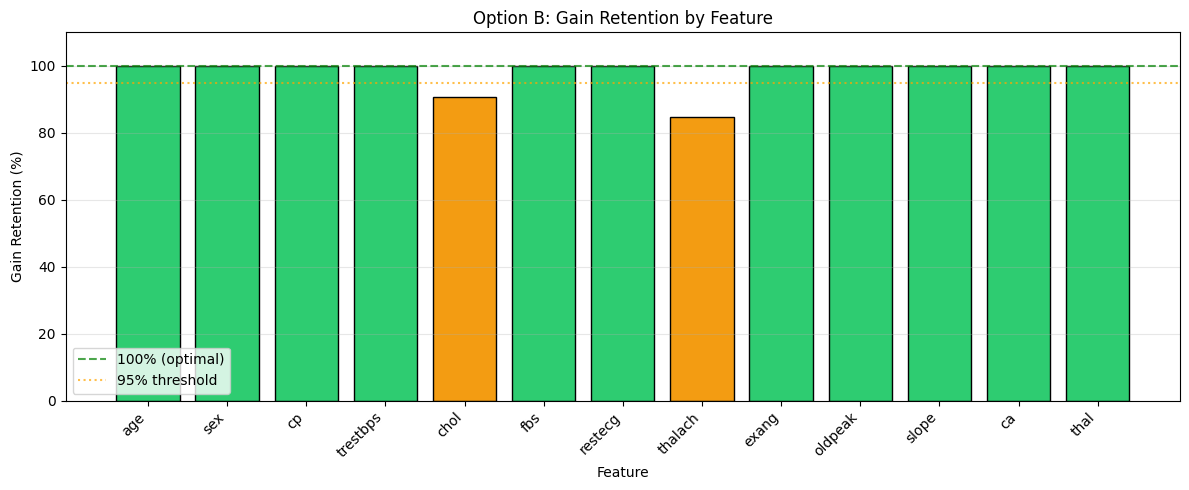


Mean gain retention: 98.1%
Min gain retention: 84.7% (thalach)


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

features = [row['feature'] for row in all_features_data]
retentions = [row['gain_retention'] for row in all_features_data]

colors = ['#2ecc71' if r >= 95 else '#f39c12' if r >= 80 else '#e74c3c' for r in retentions]

bars = ax.bar(features, retentions, color=colors, edgecolor='black')

ax.axhline(100, color='green', linestyle='--', alpha=0.7, label='100% (optimal)')
ax.axhline(95, color='orange', linestyle=':', alpha=0.7, label='95% threshold')

ax.set_ylabel('Gain Retention (%)')
ax.set_xlabel('Feature')
ax.set_title('Option B: Gain Retention by Feature')
ax.set_ylim(0, 110)
ax.legend()
plt.xticks(rotation=45, ha='right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nMean gain retention: {np.mean(retentions):.1f}%")
print(f"Min gain retention: {np.min(retentions):.1f}% ({features[np.argmin(retentions)]})")

### Option C: Threshold Error Heatmap

Single row heatmap showing |privateboost - optimal| / range for each feature. Darker = more error.

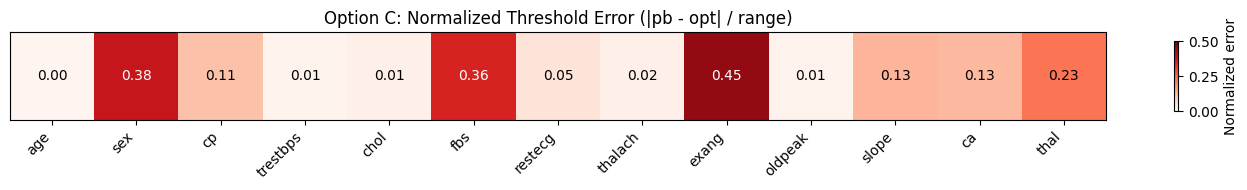

In [15]:
fig, ax = plt.subplots(figsize=(14, 2))

# Compute normalized error
errors = []
for row in all_features_data:
    if row['threshold_diff'] is not None and row['feat_range'] > 0:
        errors.append(row['threshold_diff'] / row['feat_range'])
    else:
        errors.append(0)

errors = np.array(errors).reshape(1, -1)

im = ax.imshow(errors, cmap='Reds', aspect='auto', vmin=0, vmax=0.5)

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right')
ax.set_yticks([])
ax.set_title('Option C: Normalized Threshold Error (|pb - opt| / range)')

# Add text annotations
for i in range(len(FEATURES)):
    text = ax.text(i, 0, f'{errors[0, i]:.2f}', ha='center', va='center', 
                   color='white' if errors[0, i] > 0.25 else 'black', fontsize=10)

plt.colorbar(im, ax=ax, label='Normalized error', shrink=0.8)
plt.tight_layout()
plt.show()

### Option D: Side-by-Side Threshold Plot

For each feature, shows both optimal and privateboost thresholds as paired dots on the feature's value range.

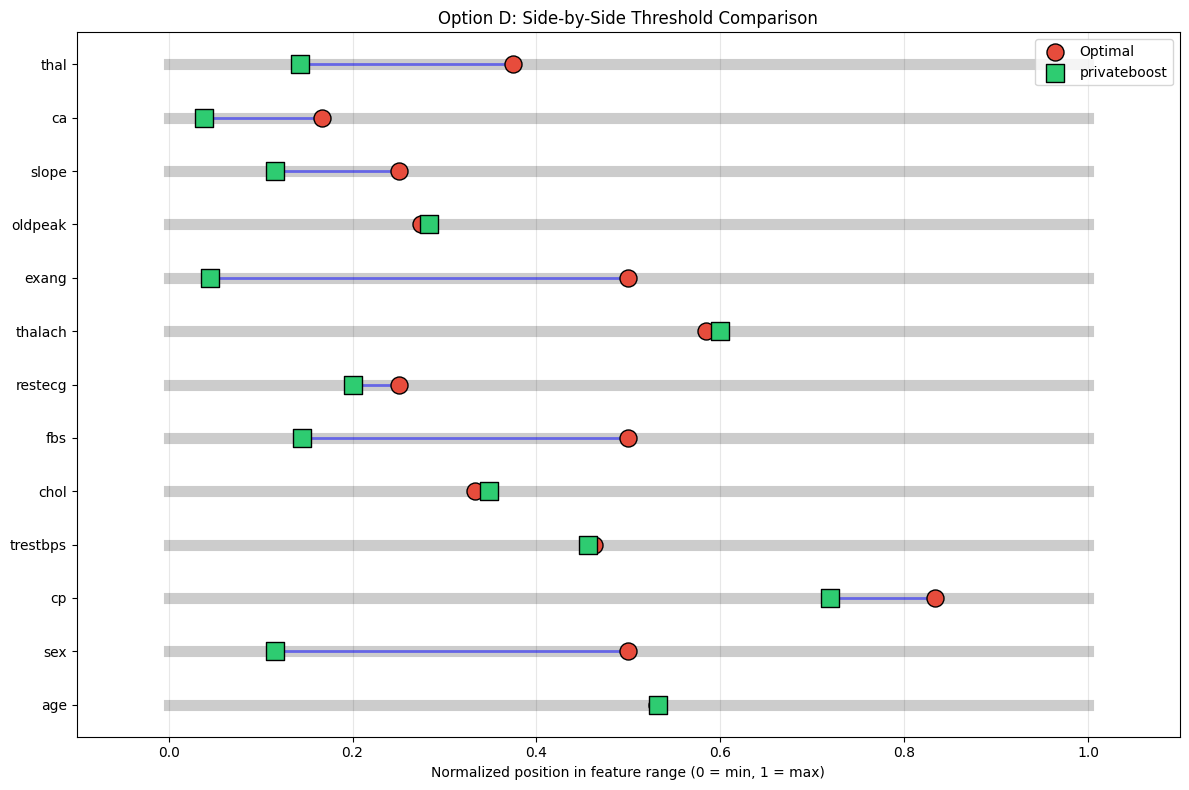

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))

y_positions = np.arange(len(FEATURES))

for i, row in enumerate(all_features_data):
    # Draw feature range as a gray line
    ax.plot([0, 1], [i, i], 'k-', alpha=0.2, linewidth=8)
    
    # Normalize thresholds
    if row['feat_range'] > 0:
        if row['opt_threshold'] is not None:
            opt_n = (row['opt_threshold'] - row['feat_min']) / row['feat_range']
            ax.scatter(opt_n, i, s=150, c='#e74c3c', marker='o', edgecolor='black', 
                      label='Optimal' if i == 0 else '', zorder=5)
        
        if row['pb_threshold'] is not None:
            pb_n = (row['pb_threshold'] - row['feat_min']) / row['feat_range']
            ax.scatter(pb_n, i, s=150, c='#2ecc71', marker='s', edgecolor='black',
                      label='privateboost' if i == 0 else '', zorder=5)
        
        # Draw connecting line
        if row['opt_threshold'] is not None and row['pb_threshold'] is not None:
            ax.plot([opt_n, pb_n], [i, i], 'b-', alpha=0.5, linewidth=2)

ax.set_yticks(y_positions)
ax.set_yticklabels(FEATURES)
ax.set_xlabel('Normalized position in feature range (0 = min, 1 = max)')
ax.set_title('Option D: Side-by-Side Threshold Comparison')
ax.set_xlim(-0.1, 1.1)
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()